In [2]:
import pandas as pd

# Load the Benin dataset
df = pd.read_csv("C:/Users/nati/Downloads/solar-challenge-week1/data/data/togo-dapaong_qc.csv")

# Preview the first few rows
df.head()


,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
0,2021-10-25 00:01,-1.3,0.0,0.0,0.0,0.0,24.8,94.5,0.9,1.1,0.4,227.6,1.1,977,0,0.0,24.7,24.4,NaN
1,2021-10-25 00:02,-1.3,0.0,0.0,0.0,0.0,24.8,94.4,1.1,1.6,0.4,229.3,0.7,977,0,0.0,24.7,24.4,NaN
2,2021-10-25 00:03,-1.3,0.0,0.0,0.0,0.0,24.8,94.4,1.2,1.4,0.3,228.5,2.9,977,0,0.0,24.7,24.4,NaN
3,2021-10-25 00:04,-1.2,0.0,0.0,0.0,0.0,24.8,94.3,1.2,1.6,0.3,229.1,4.6,977,0,0.0,24.7,24.4,NaN
4,2021-10-25 00:05,-1.2,0.0,0.0,0.0,0.0,24.8,94.0,1.3,1.6,0.4,227.5,1.6,977,0,0.0,24.7,24.4,NaN


In [3]:
# Summary statistics
df.describe()

# Missing values
missing_report = df.isna().sum()
missing_percent = (missing_report / len(df)) * 100
missing_report[missing_percent > 5]


Comments    525600
dtype: int64

In [4]:
from scipy.stats import zscore

columns_to_check = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']
z_scores = df[columns_to_check].apply(zscore)

# Flagging outliers
outliers = (z_scores.abs() > 3)
outlier_rows = outliers.any(axis=1)
print("Outlier rows:", outlier_rows.sum())


Outlier rows: 9251


In [5]:
# Drop rows or impute with median
df_clean = df.copy()
df_clean[columns_to_check] = df_clean[columns_to_check].fillna(df_clean[columns_to_check].median())


In [6]:
import os

# Create outputs/ folder if it doesn't exist
os.makedirs('../outputs', exist_ok=True)

# Now save the cleaned CSV
df_clean.to_csv('../outputs/togo-dapaong_qc.csv', index=False)


In [7]:
df_clean.to_csv('../outputs/togo-dapaong_qc.csv', index=False)


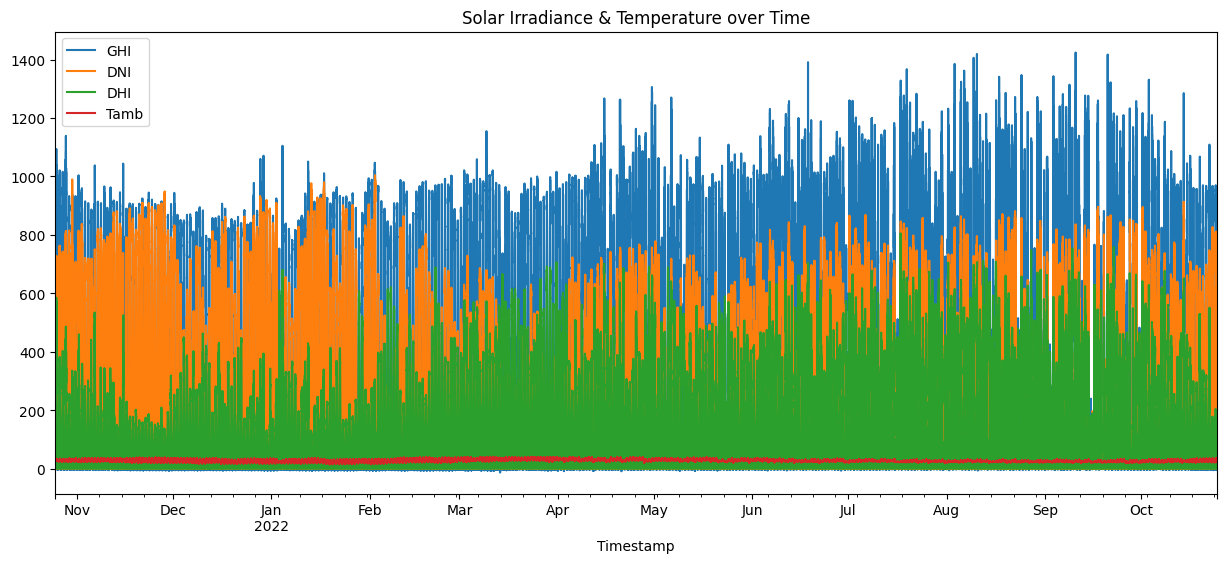

In [8]:
import matplotlib.pyplot as plt

df_clean['Timestamp'] = pd.to_datetime(df_clean['Timestamp'])
df_clean.set_index('Timestamp', inplace=True)

df_clean[['GHI', 'DNI', 'DHI', 'Tamb']].plot(figsize=(15,6))
plt.title('Solar Irradiance & Temperature over Time')
plt.show()


<Axes: title={'center': 'Effect of Cleaning on ModA & ModB'}, xlabel='Cleaning'>

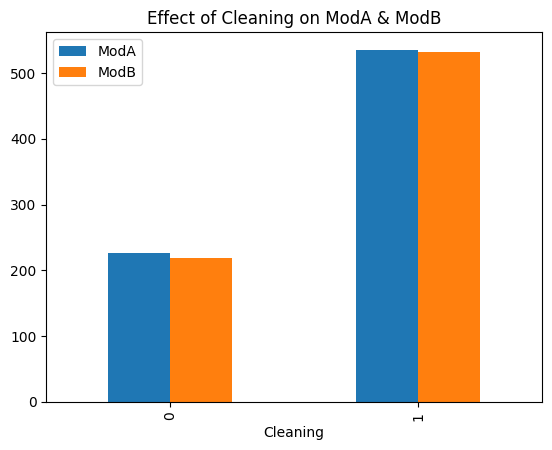

In [9]:
df_clean.groupby('Cleaning')[['ModA', 'ModB']].mean().plot(kind='bar', title='Effect of Cleaning on ModA & ModB')


<Axes: >

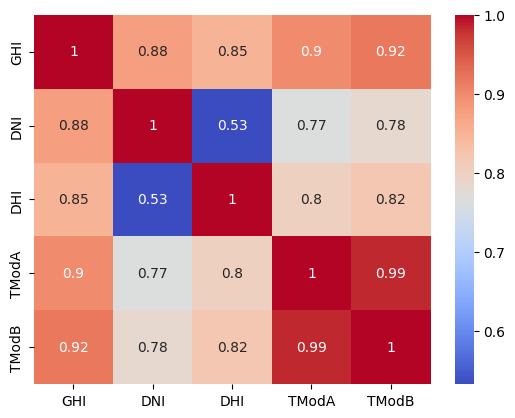

In [11]:
import seaborn as sns

corr = df_clean[['GHI', 'DNI', 'DHI', 'TModA', 'TModB']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')


<Axes: xlabel='WS', ylabel='GHI'>

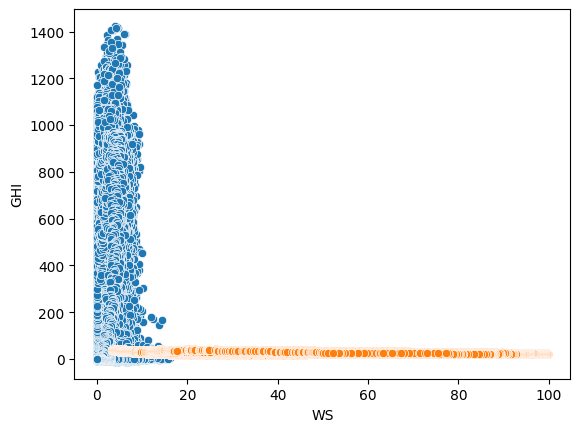

In [12]:
sns.scatterplot(data=df_clean, x='WS', y='GHI')
sns.scatterplot(data=df_clean, x='RH', y='Tamb')


<Axes: >

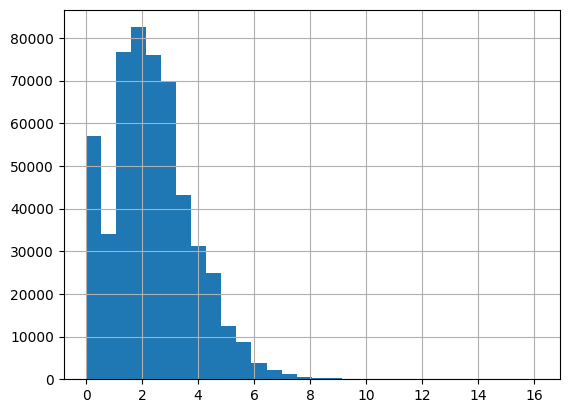

In [13]:
df_clean['WS'].hist(bins=30)


In [14]:
pip install windrose


Note: you may need to restart the kernel to use updated packages.


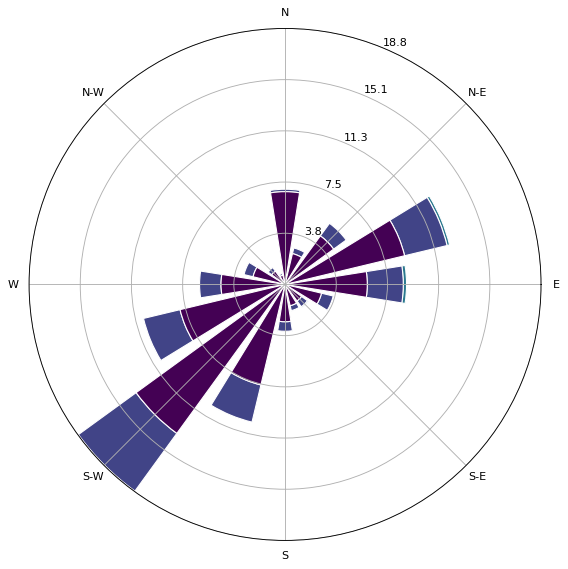

In [15]:
from windrose import WindroseAxes

ax = WindroseAxes.from_ax()
ax.bar(df_clean['WD'], df_clean['WS'], normed=True, opening=0.8, edgecolor='white')


<Axes: xlabel='RH', ylabel='Tamb'>

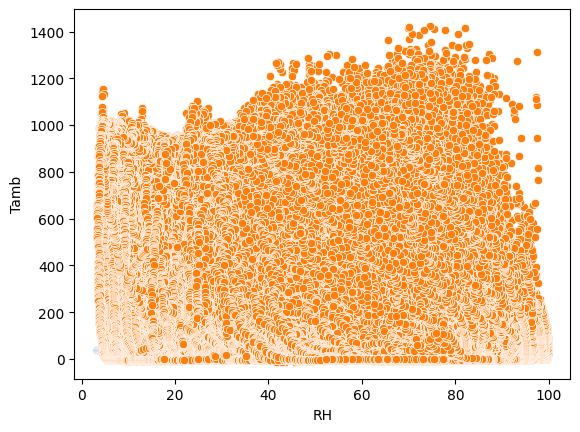

In [16]:
sns.scatterplot(data=df_clean, x='RH', y='Tamb')
sns.scatterplot(data=df_clean, x='RH', y='GHI')


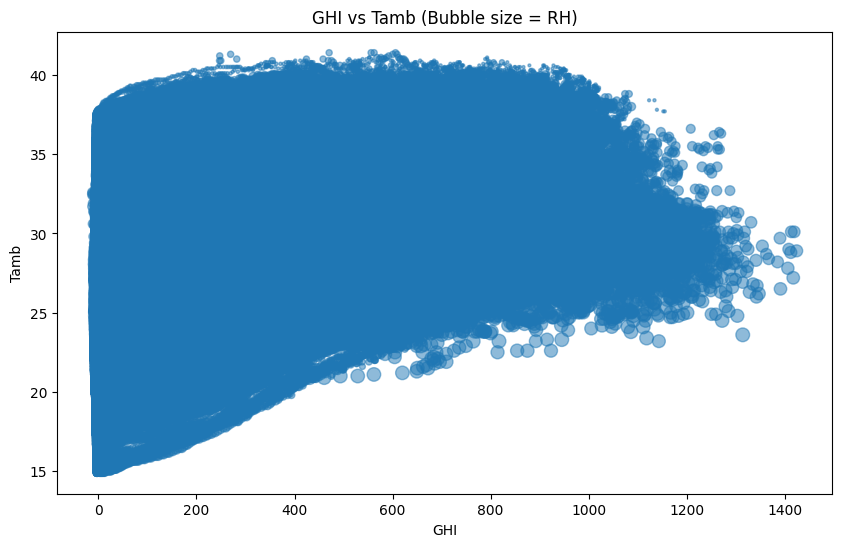

In [17]:
plt.figure(figsize=(10,6))
plt.scatter(df_clean['GHI'], df_clean['Tamb'], s=df_clean['RH'], alpha=0.5)
plt.xlabel('GHI')
plt.ylabel('Tamb')
plt.title('GHI vs Tamb (Bubble size = RH)')
plt.show()
